# California Housing Price Prediction

### Overview
The California Housing Price Prediction project involves using the California Housing dataset to predict house prices based on various features. This dataset provides an alternative to the Boston Housing dataset and offers a chance to explore regression algorithms and model evaluation techniques.

### Dataset
The California Housing dataset is available in the `sklearn.datasets` module. It contains data on housing in California, including features such as latitude, longitude, and average income. The target variable is the median house value.

### Objectives

#### Data Exploration and Preprocessing:
- Load the California Housing dataset.
- Inspect the dataset for missing values and basic statistics.
- Preprocess the data by scaling features and splitting the dataset into training and testing sets.

#### Exploratory Data Analysis (EDA):
- Analyze the distribution of each feature.
- Visualize relationships between features and the target variable using scatter plots and correlation matrices.
- Assess the distribution of the target variable.

#### Model Building and Evaluation:
- Build regression models using algorithms like Linear Regression, Ridge Regression, and Lasso Regression.
- Evaluate model performance using metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

#### Model Tuning:
- Fine-tune hyperparameters to improve model performance.
- Use techniques like cross-validation to assess model stability and performance.

### Methods and Tools

#### Libraries Used:
- `scikit-learn` for machine learning algorithms and preprocessing.
- `numpy` and `pandas` for data manipulation.
- `matplotlib` and `seaborn` for data visualization.

Linear Regression Performance:
Mean Absolute Error: 0.53
Mean Squared Error: 0.56
R-squared: 0.58

Ridge Regression Performance:
Mean Absolute Error: 0.53
Mean Squared Error: 0.56
R-squared: 0.58

Lasso Regression Performance:
Mean Absolute Error: 0.58
Mean Squared Error: 0.61
R-squared: 0.53



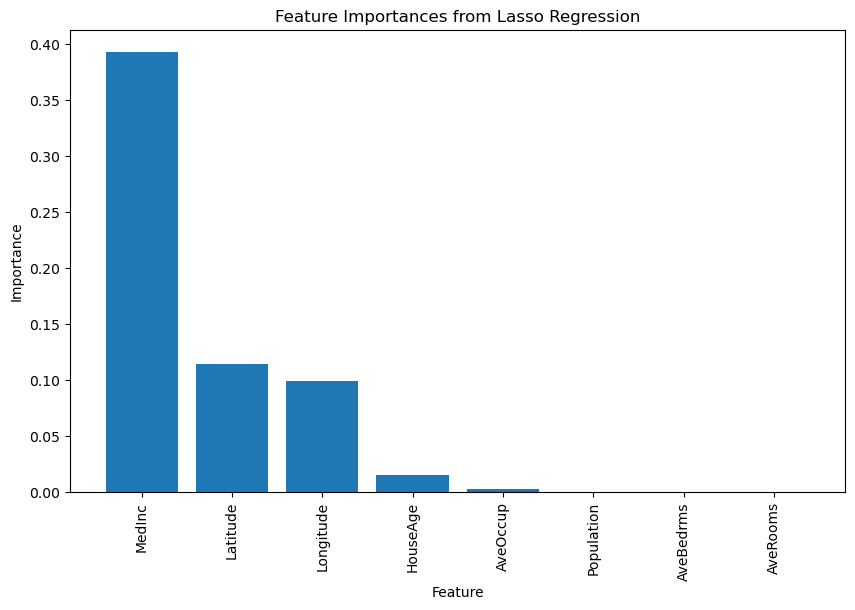

In [10]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MEDV')

# Data Preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)

# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_predictions = lasso_model.predict(X_test)

# Evaluate models
def evaluate_model(y_true, y_pred, model_name):
    print(f"{model_name} Performance:")
    print(f"Mean Absolute Error: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"Mean Squared Error: {mean_squared_error(y_true, y_pred):.2f}")
    print(f"R-squared: {r2_score(y_true, y_pred):.2f}")
    print()

evaluate_model(y_test, lr_predictions, 'Linear Regression')
evaluate_model(y_test, ridge_predictions, 'Ridge Regression')
evaluate_model(y_test, lasso_predictions, 'Lasso Regression')

# Plot feature importances for Lasso Regression
plt.figure(figsize=(10, 6))
feature_importances = np.abs(lasso_model.coef_)
features = X.columns
sorted_idx = np.argsort(feature_importances)[::-1]
plt.bar(range(X.shape[1]), feature_importances[sorted_idx], align='center')
plt.xticks(range(X.shape[1]), features[sorted_idx], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances from Lasso Regression')
plt.show()